## 🧠💡 Intelligent Systems  for Smart Health 👨‍⚕👩‍⚕️🔬🌡️

# Portfolio Exercise 2 - Ocular Disease Recognition
## CNN (Convolutional Neural Networks)

Convolutional Neural Networks, or CNNs for short, are a powerful type of neural network commonly used in computer vision tasks. They are particularly well-suited to tasks like image classification and object detection because they are able to automatically learn and extract relevant features from input images. CNNs consist of multiple layers, each of which performs a different type of processing on the input data. These layers typically include convolutional layers, which extract features from the input images, and pooling layers, which downsample the output of the convolutional layers. By stacking these layers on top of one another, a CNN is able to learn increasingly complex representations of the input data.

In [1]:
# Imports necessary for data handling/import/exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

import warnings

# Suppress FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Imports necessary for deep learning model
import torch.nn as nn
from torchvision import models, transforms
import torch.nn.functional as F

## Dataset



Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords from doctors.

This dataset is meant to represent ‘‘real-life’’ set of patient information collected by Shanggong Medical Technology Co., Ltd. from different hospitals/medical centers in China. In these institutions, fundus images are captured by various cameras in the market, such as Canon, Zeiss and Kowa, resulting into varied image resolutions.

Annotations were labeled by trained human readers with quality control management. They classify patient into eight labels including:

* Normal (N),
* Diabetes (D),
* Glaucoma (G),
* Cataract (C),
* Age related Macular Degeneration (A),
* Hypertension (H),
* Pathological Myopia (M),
* Other diseases/abnormalities (O)



In [4]:
class_name_dict = {
    "N": "Normal",
    "D": "Diabetes",
    "G": "Glaucoma",
    "C": "Cataract",
    "A": "Age related Macular Degeneration",
    "H": "Hypertension",
    "M": "Pathological Myopia",
}

## 1. Import, Exploration, Cleaning

Read the data from `csv` files and explore the data.

- What are medically useful labels to train a deep learning network on?
- Are there any biases we need to consider?
- Do we have to worry about "data leakage", something that often comes from having many datapoints for the same patients ?

#### Datensatzerkundung

In [5]:
path_data = "ocular_disease_recognition_small"

metadata = pd.read_csv(os.path.join(path_data, "metadata.csv"))
metadata.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,filename,left_cataract,right_cataract
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,0_right.jpg,1,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,1_right.jpg,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,2_right.jpg,0,0
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,4_right.jpg,0,0
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,5_right.jpg,0,0


In [6]:
metadata.shape

(6392, 19)

In [7]:
len(metadata.ID.unique())

3358

In [8]:
label_column = ['N', 'D' , 'G' ,'C', 'A', 'H', 'M', 'O']

In [9]:
metadata[label_column].sum(axis=0)

N    2101
D    2123
G     397
C     402
A     319
H     203
M     306
O    1588
dtype: int64

In [10]:
(metadata['Left-Diagnostic Keywords'] == metadata['Right-Diagnostic Keywords']).value_counts()

True     3692
False    2700
Name: count, dtype: int64

In [11]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 non-null   int64 
 14  O       

#### What are medically useful labels to train a deep learning network on?

Ohne Weiterverarbeitung der Metadaten würden sich sowohl die Annotierten Label *N, D, G, C, A, H, M & O* eignen also auch *left/right_cateract*. Diese Label liegen schon in Binärer form vor. *left/right_cateract* ist dementsprechend auch genau einem Bild zuzuordnen, während *N, D, G, C, A, H, M & O* jeweils für die Kombination aus dem linken und rechtem Bild gilt. 

Das führt zu einigen Problemen mit den Daten. Manche Augen haben weisen laut diagnose keywords nur auf einer Seite Merkmale auf. D.h. würde man die Label für ein paar für beide Bilder einzeln Übernehmen, würde das zu Teilweise falschen labeln und noise führen. Diese noise könnte in mehreren Graden reduziert werden. Augen die die Diagnose "normal fundus" haben bekommen alle label auf 0 gesetzt. Das könnte die Noise bereits stark reduzieren. Der Fall eines Bildpaares indem ein Merkmal was für D spricht auf dem linken und ein Merkmal was auf C hindeutet im rechtem Bild zu finden ist, wäre allerdings noch nicht abgedeckt. 

Zu überprüfen bei welchen Diagnostic Keywords welche label gefunden wurden kann man die Keywords mit 'get_Dummies()' ebenfalls in label umwandeln. Mit den Dummies kann man dann überprüfen label bei welchen Diagnostic Keywords immer auftreten. Für Keywords die nur sehr selten vorkommen bietet dieses verfahren eine gewisse ungenauigkeit.


In [12]:
metadata_no_duplicate_IDs = metadata.drop_duplicates(subset='ID')

In [13]:
metadata_no_duplicate_IDs['Diagnostic Keywords'] = (metadata_no_duplicate_IDs['Right-Diagnostic Keywords'] + ',' + metadata_no_duplicate_IDs['Left-Diagnostic Keywords'])

C:\Users\sundl\AppData\Local\Temp\ipykernel_19952\806052286.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_no_duplicate_IDs['Diagnostic Keywords'] = (metadata_no_duplicate_IDs['Right-Diagnostic Keywords'] + ',' + metadata_no_duplicate_IDs['Left-Diagnostic Keywords'])


In [14]:
metadata_dk_cleaned = metadata_no_duplicate_IDs['Diagnostic Keywords'].str.replace(r'/s', '', regex=True)
metadata_dk_cleaned = metadata_dk_cleaned.str.replace(r'[,，]', ';', regex=True)
metadata_dummies= metadata_dk_cleaned.str.get_dummies(sep= ';')

In [15]:
diagnostic_keywords = list(metadata_dummies.columns)

In [16]:
metadata_with_dummies = pd.concat([metadata_no_duplicate_IDs, metadata_dummies], axis=1)

In [17]:
metadata_with_dummies.shape

(3358, 114)

Erstellen einer Matrix die zeigt welche Keywords mit welchen labeln auftreten:

In [18]:
conf_matrix = pd.DataFrame(index=diagnostic_keywords, columns=label_column, dtype=float)

for A in diagnostic_keywords:
    for B in label_column:
        A_true = metadata_with_dummies[A] == 1
        if A_true.sum() == 0:
            conf_matrix.loc[A, B] = np.nan  
        else:
            conf_matrix.loc[A, B] = metadata_with_dummies.loc[A_true, B].mean()



In [19]:
conf_matrix['D'].nlargest(20)

diabetic retinopathy                                1.000000
glial remnants anterior to the optic disc           1.000000
intraretinal microvascular abnormality              1.000000
macular pigmentation disorder                       1.000000
mild nonproliferative retinopathy                   1.000000
moderate non proliferative retinopathy              1.000000
no fundus image                                     1.000000
old choroiditis                                     1.000000
optic disk epiretinal membrane                      1.000000
pigmentation disorder                               1.000000
proliferative diabetic retinopathy                  1.000000
retinal pigment epithelial hypertrophy              1.000000
retinal pigment epithelium atrophy                  1.000000
severe nonproliferative retinopathy                 1.000000
severe proliferative diabetic retinopathy           1.000000
suspected diabetic retinopathy                      1.000000
suspected microvascular 

In [20]:
conf_matrix[label_column[2]][(conf_matrix[label_column[2]]> 0.99)]

diffuse retinal atrophy                1.0
fundus laser photocoagulation spots    1.0
glaucoma                               1.0
image offset                           1.0
intraretinal hemorrhage                1.0
macular pigmentation disorder          1.0
old central retinal vein occlusion     1.0
pigmentation disorder                  1.0
suspected cataract                     1.0
suspected glaucoma                     1.0
suspicious diabetic retinopathy        1.0
Name: G, dtype: float64

In [21]:
found_keywords = set()
keyword_label_dict = {}

for label in label_column:
    print('\n'+ label)
    conf_label = dict(conf_matrix[label][(conf_matrix[label]> 0.99)])
    for keyword_name in conf_label:
        print(keyword_name)
        if keyword_name in keyword_label_dict:
            keyword_label_dict[keyword_name].append(label)
        else:
            keyword_label_dict[keyword_name] = [label]
        found_keywords.add(keyword_name)



N

D
diabetic retinopathy
glial remnants anterior to the optic disc
intraretinal microvascular abnormality
macular pigmentation disorder
mild nonproliferative retinopathy
moderate non proliferative retinopathy
no fundus image
old choroiditis
optic disk epiretinal membrane
pigmentation disorder
proliferative diabetic retinopathy
retinal pigment epithelial hypertrophy
retinal pigment epithelium atrophy
severe nonproliferative retinopathy
severe proliferative diabetic retinopathy
suspected diabetic retinopathy
suspected microvascular anomalies
suspected moderate non proliferative retinopathy
suspicious diabetic retinopathy

G
diffuse retinal atrophy
fundus laser photocoagulation spots
glaucoma
image offset
intraretinal hemorrhage
macular pigmentation disorder
old central retinal vein occlusion
pigmentation disorder
suspected cataract
suspected glaucoma
suspicious diabetic retinopathy

C
cataract
suspected cataract

A
age-related macular degeneration
central serous chorioretinopathy
choro

Wie viele der gesamten Keywords konnten wir matchen? Welche fehlen?

In [22]:
print(len(found_keywords))
print(len(diagnostic_keywords))
print(set(diagnostic_keywords).difference(found_keywords))

90
94
{'normal fundus', 'lens dust', 'optic disk photographically invisible', 'low image quality'}


Die nicht gefunden Keywords sind alle okay. 'normal fundus' kann nicht zugeordnet werden, da es nicht zwangsweise ein label setzt und häufig von befunden im anderem Auge überschrieben wird. Die anderen drei beschreiben die Bildqualität.  

Manche Keywords haben mehrere label zugewiesen bekommen. Dies könnte natürlich korrekt sein, oder auftreten wenn ein Befund immer zusammen mit den anderen Befunden auftritt. Das kann bei befunden die nur selten bis einmal vorkommen schnell passieren.

In [23]:
multi_label_keywords = 0
unsure_mappings = []

for key in keyword_label_dict:
    if len(keyword_label_dict.get(key))> 1:
        multi_label_keywords += metadata_dummies[key].sum()
        unsure_mappings.append(key)
        print(key + ': ' + str(keyword_label_dict.get(key)))
print('total dropped samples: ' + str(2*multi_label_keywords))

glial remnants anterior to the optic disc: ['D', 'O']
intraretinal microvascular abnormality: ['D', 'O']
macular pigmentation disorder: ['D', 'G', 'O']
old choroiditis: ['D', 'O']
optic disk epiretinal membrane: ['D', 'O']
pigmentation disorder: ['D', 'G', 'O']
retinal pigment epithelial hypertrophy: ['D', 'O']
retinal pigment epithelium atrophy: ['D', 'O']
suspected diabetic retinopathy: ['D', 'H']
suspected microvascular anomalies: ['D', 'O']
suspected moderate non proliferative retinopathy: ['D', 'M']
suspicious diabetic retinopathy: ['D', 'G']
diffuse retinal atrophy: ['G', 'O']
fundus laser photocoagulation spots: ['G', 'O']
image offset: ['G', 'A']
intraretinal hemorrhage: ['G', 'O']
old central retinal vein occlusion: ['G', 'O']
suspected cataract: ['G', 'C']
central serous chorioretinopathy: ['A', 'O']
choroidal nevus: ['A', 'O']
diffuse chorioretinal atrophy: ['A', 'O']
vitreous opacity: ['H', 'O']
peripapillary atrophy: ['M', 'O']
retinal detachment: ['M', 'O']
suspected macu

manuell überprüfen, ob andere eindeutige keywords in den Metadaten endscheiden können. Manchmal geben auch die Namen ein eindeutigen Hinweis.

In [24]:
keyword_label_dict['glial remnants anterior to the optic disc'] = ['O']
keyword_label_dict['intraretinal microvascular abnormality'] = ['O']
keyword_label_dict['macular pigmentation disorder'] = ['O']
keyword_label_dict['old choroiditis'] = ['O']
keyword_label_dict['optic disk epiretinal membrane'] = ['O']
keyword_label_dict['pigmentation disorder'] = ['O']
keyword_label_dict['retinal pigment epithelial hypertrophy'] = ['O']
keyword_label_dict['retinal pigment epithelium atrophy'] = ['O']
keyword_label_dict['suspected diabetic retinopathy'] = ['D']
keyword_label_dict['suspected microvascular anomalies'] = ['O']
keyword_label_dict['suspected moderate non proliferative retinopathy'] = ['D']
keyword_label_dict['suspicious diabetic retinopathy'] = ['D']
keyword_label_dict['diffuse retinal atrophy'] = ['O']
keyword_label_dict['fundus laser photocoagulation spots'] = ['O']
keyword_label_dict['intraretinal hemorrhage'] = ['O']
keyword_label_dict['old central retinal vein occlusion'] = ['O']
keyword_label_dict['suspected cataract'] = ['C']
keyword_label_dict['central serous chorioretinopathy'] = ['O']
keyword_label_dict['choroidal nevus'] = ['O']
keyword_label_dict['diffuse chorioretinal atrophy'] = ['O']
keyword_label_dict['vitreous opacity'] = ['O']
keyword_label_dict['peripapillary atrophy'] = ['O']
keyword_label_dict['retinal detachment'] = ['O']
keyword_label_dict['suspected macular epimacular membrane'] = ['O']

Bild Quallitäts beschreibungs Keyword 'image offset' aus dem mapping dict entfernen:

In [25]:
keyword_label_dict.pop('image offset')

['G', 'A']

Andere quality_keywords:

In [26]:
quality_keywords = ['lens dust', 'image offset', 'low image quality', 'optic disk photographically invisible']

Bis auf 'lense dust' gibt es keine dieser Keywords in einem eintrag, wo der filename auf die keyword enthaltene Augenseite zeigt.

#### Are there any biases we need to consider?

Gender Biases oderr Age?

<Axes: >

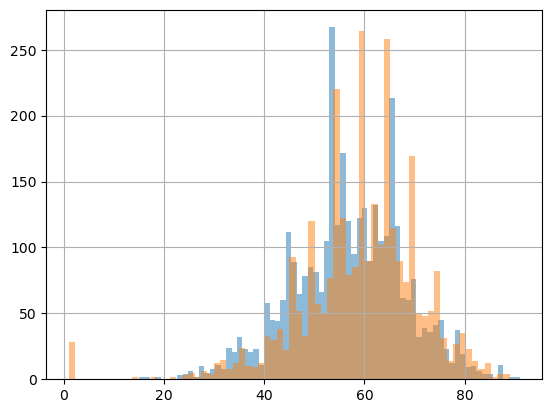

In [27]:
metadata[metadata['Patient Sex']=='Male']['Patient Age'].hist(alpha=0.5,bins=70)
metadata[metadata['Patient Sex']=='Female']['Patient Age'].hist(alpha=0.5,bins=70)

In [28]:
metadata[metadata['Patient Sex']=='Male'][label_column].sum()/metadata[label_column].sum()

N    0.558782
D    0.557230
G    0.579345
C    0.417910
A    0.542320
H    0.625616
M    0.352941
O    0.503149
dtype: float64

In [29]:
metadata[metadata['Patient Sex']=='Female'][label_column].sum()/metadata[label_column].sum()

N    0.441218
D    0.442770
G    0.420655
C    0.582090
A    0.457680
H    0.374384
M    0.647059
O    0.496851
dtype: float64

In [30]:
metadata[label_column].sum()

N    2101
D    2123
G     397
C     402
A     319
H     203
M     306
O    1588
dtype: int64

Beim Training müssen die verteilung der Label besonders berücksichtigen. Die Klassen *N, D, O* sind relativ gebalanced, während die anderen bis zu 10 mal unterrepräsentiert sind.

#### Do we have to worry about "data leakage", something that often comes from having many datapoints for the same patients ?

Wenn wir den Datensatzt unbereinigt nutzen und die Label zusammen mit filename nutzen würden, hätten wir einige label Doppelt mit relativ ähnlichen Augen. Da die doppelten Patienten IDs zwar von der selben Person aber immer von anderem Auge, ist dieses 'leakage' zwar vorhanden nicht gravierend. Selbst wenn die Bilder beinahe identische Merkmale aufweisen wären sie noch mindestens gespiegelt. Nicht jede ID ist zweimal vertreten.

Ein größeres Problem wären die bereits thematisierten unverlässlichen Label.

## Have a look at some of the images

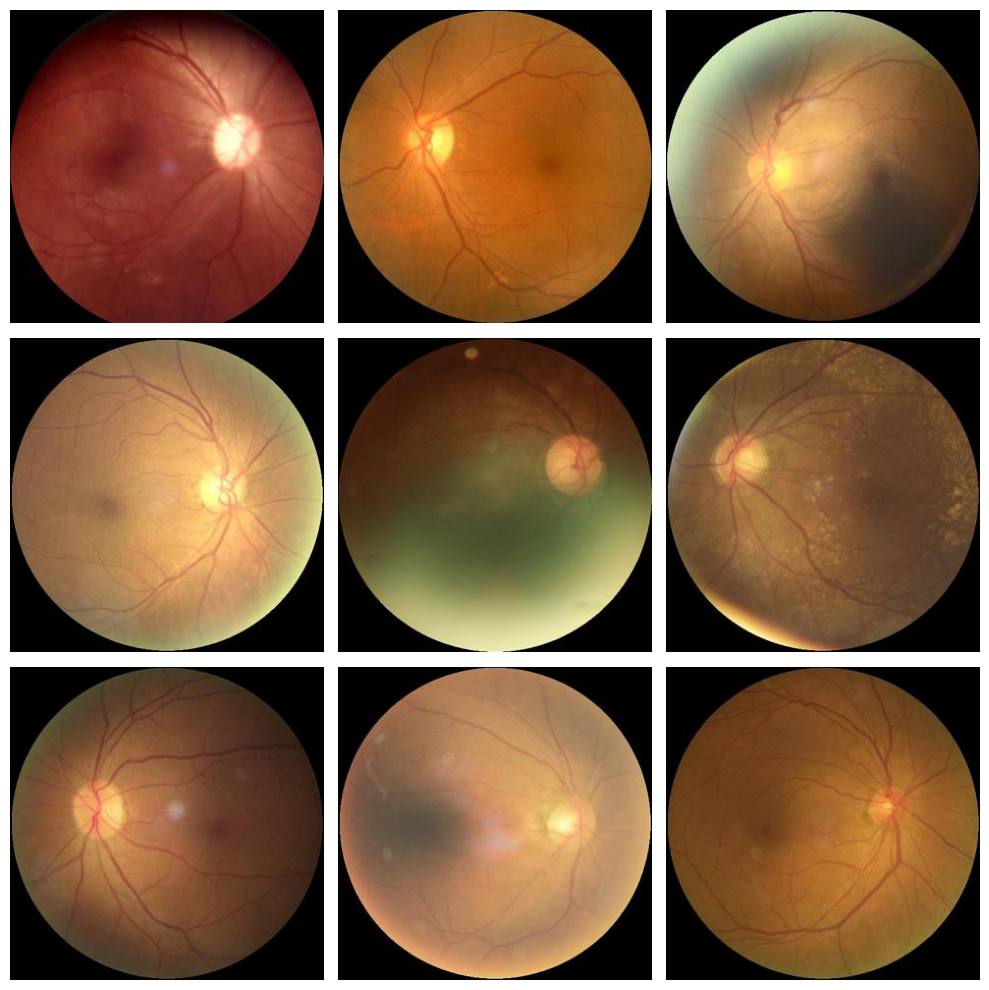

In [31]:
path_images = r"E:\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small"

# Pick 9 random images
np.random.seed(2)
random_images = np.random.choice(metadata.filename, 9)

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i, filename in enumerate(random_images):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(path_images, filename))
    plt.imshow(img)
    plt.axis('off')
    
# Adjust subplot parameters to give specified padding
plt.tight_layout()    

## 2. Prepare data for machine learning: 
- Separate data / labels
- Split into train ~70% / validation ~15% / test ~15%

In [32]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(metadata,
                                     test_size=0.2,
                                     random_state=0
                                    )
print(f"Training set size: {train_df.shape}")
print(f"Test set size: {test_df.shape}")

# second split
test_df, val_df = train_test_split(test_df,
                                    test_size=0.5,
                                    random_state=0
                                    )
print(f"Training set size: {train_df.shape}")
print(f"Validation set size: {val_df.shape}")
print(f"Test set size: {test_df.shape}")

Training set size: (5113, 19)
Test set size: (1279, 19)
Training set size: (5113, 19)
Validation set size: (640, 19)
Test set size: (639, 19)


Splitten der Daten Später?

## 3. Build an image generator pipeline
- Create a Pytroch `Dataset` child class `train_dataset` and a `validation_dataset` (feel free to adapt the `XRayDataset` from the pytorch_utils.py)
- Use the generator to recale the pixel values and to reshape the image to the desired format.
- Use the Pytorch `DataLoader` as a generator for the later training:
```python
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
```

In [33]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image, ImageReadMode
from torchvision import transforms

class OcularDataset(Dataset):
    """
    A custom PyTorch Dataset class for chest ocular images.

    This class is designed to handle ocular image datasets, supporting both grayscale
    and RGB image modes. It allows for on-the-fly transformations of the images and labels,
    facilitating data augmentation and preprocessing steps.

    Parameters:
    - metadata (pd.DataFrame): DataFrame containing image metadata (e.g., filenames, labels).
    - img_dir (str): Directory path where images are stored.
    - classes (list): List of Label column names in `metadata` representing the label(s) for each image. Accepting each ['N', 'D' , 'G' ,'C', 'A', 'H', 'M', 'O']
    - img_mode (str, optional): The mode of the images, either "RGB" or "GRAY". Default is "RGB".
    - transform (callable, optional): A function/transform that takes in an image and returns a transformed version. E.g., data augmentation procedures.
    - target_transform (callable, optional): A function/transform that takes in the target and transforms it.
    - filename_prefix (str, optional): Prefix to add to filenames from `metadata` before loading images. Useful if `metadata` filenames do not include a common path prefix that is present in `img_dir`.

    Usage:
    dataset = XRayDataset(metadata=df, img_dir="/path/to/images", classes=['Normal', 'Pneumonia'], img_mode='RGB')
    """
    def __init__(
        self,
        metadata: pd.DataFrame,
        img_dir: str,
        classes: list,
        keyword_label_dict: dict,
        img_mode: str = "RGB",
        transform=None,
        target_transform=None,
    ):
        self.img_metadata = metadata
        self.img_dir = img_dir
        self.classes = classes
        if img_mode.lower() == "rgb":
            self.img_mode = ImageReadMode.RGB
        elif img_mode.lower() == "gray":
            self.img_mode = ImageReadMode.GRAY
        else:
            raise ValueError("Unknown image mode (img_mode), must be GRAY or RGB.")
        self.transform = transform
        self.target_transform = target_transform
        self.keyword_label_dict = keyword_label_dict

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.img_metadata)

    def __getitem__(self, idx):
        """Retrieves the image and its label at the specified index `idx`.

        Parameters:
        - idx (int): Index of the item to retrieve.

        Returns:
        - tuple: (image, label) where image is the transformed image tensor, and label is the corresponding label tensor.
        """
        # Construct the full path to the image file
        img_path = os.path.join(self.img_dir, self.img_metadata['filename'].iloc[idx])
 
        # Read the image file
        image = read_image(img_path, mode=self.img_mode)
        image = image.to(torch.float32)/255

        # Extract label(s) for the current image
        if 'left' in self.img_metadata['filename'].iloc[idx]:
            diagnostic_keywords = self.img_metadata['Left-Diagnostic Keywords'].str.replace(r'/s', '', regex=True).replace(r'[,，]', ';', regex=True).iloc[idx]
        elif 'right' in self.img_metadata['filename'].iloc[idx]:
            diagnostic_keywords = self.img_metadata['Right-Diagnostic Keywords'].str.replace(r'/s', '', regex=True).replace(r'[,，]', ';', regex=True).iloc[idx]
            
        diagnostic_keywords = diagnostic_keywords.split(sep=';')
        label_set = set()

        for keyword in diagnostic_keywords:
            if keyword == 'lens dust':
                continue
            elif ('N' in self.classes) and (keyword == 'normal fundus'):
                label_set.add('N')
            else:
                label = self.keyword_label_dict.get(keyword)
                if label != None:
                    label = label[0]
                if label in self.classes:
                    label_set.add(label)

        
        label = torch.tensor([1 if cls in label_set else 0 for cls in self.classes], dtype=torch.float32)

        # Apply transformations to the image and label if any
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label


## CNN Exercise 1: Build and train a CNN with 5 Convolutional layers (**binary classification**)
- Build a CNN with 5 Convolution + pooling layers for predicting one conditions ("D" --> Diabetes)
- Train with images of the size 320 x 320 (grayscale or RGB is up to you)
- Evaluate the model

In [34]:
class CNNModel(nn.Module):
    """
    A simple 5‐layer convolutional network followed by two fully connected layers.
    Input: 3×320×320 RGB image or 1×320×320 grayscale image
    Output: num_classes logistic probabilities (sigmoid)

    Parameters:
    - mode (string): 'RGB' or 'grey' to determine the size of the input channels.
    """
    def __init__(self, num_classes: int, mode='RGB'):
        super().__init__()
        if mode == 'RGB': in_channels = 3
        if mode == 'grey': in_channels = 1

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=192, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        flattened_size = 192 * 10 * 10

        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = self.pool(x)

        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))

        x = torch.sigmoid(self.fc2(x))
        return x

___________________________________________________________________________________________________________________________

Training

In [35]:
transform = transforms.Compose([
    transforms.Resize((320, 320))
])

In [36]:
train_dataset = OcularDataset(train_df,'E:\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=['D'], transform= transform,keyword_label_dict=keyword_label_dict)
val_dataset = OcularDataset(val_df,'E:\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=['D'], transform= transform,keyword_label_dict=keyword_label_dict)

In [37]:
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)

In [38]:
model = CNNModel(1, 'RGB')

In [39]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.BCELoss()

In [40]:
from torchinfo import summary
from tqdm import tqdm
summary(model)

Layer (type:depth-idx)                   Param #
CNNModel                                 --
├─Conv2d: 1-1                            896
├─Conv2d: 1-2                            18,496
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            221,376
├─Conv2d: 1-5                            331,968
├─MaxPool2d: 1-6                         --
├─Linear: 1-7                            1,228,864
├─Linear: 1-8                            65
Total params: 1,875,521
Trainable params: 1,875,521
Non-trainable params: 0

In [ ]:
def show_tensor_image(tensor_img):
    img = tensor_img.detach().cpu().numpy()
    if img.ndim == 3:
        img = img.transpose(1, 2, 0)
    plt.imshow(img, cmap='gray' if img.shape[-1] == 1 or len(img.shape) == 2 else None)
    plt.axis('off')
    plt.show()

In [43]:
def display_data(input, label):
    show_tensor_image(input)
    print(input.max())
    print(input.min())
    print(label)

In [ ]:
sssss

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

EPOCHS = 5
model = CNNModel(1, 'RGB')
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
loss_fn = nn.BCELoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training will happen on {device}.")

for epoch in range(EPOCHS):
    print(f"EPOCH {epoch + 1}")

    model.train(True)

    running_loss = 0.
    avg_loss = 0.

    for i, data in enumerate(tqdm(train_loader)):
        inputs, labels = data
        optimizer.zero_grad()
         
        outputs = model(inputs.to(device))
        loss = loss_fn(outputs, labels.to(device))
    
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_loader)


    running_vloss = 0.0
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

        print(running_vloss/len(val_loader))


    # Traking
s

Training will happen on cpu.
EPOCH 1


  1%|          | 1/103 [00:03<06:24,  3.77s/it]


KeyboardInterrupt: 

In [45]:
sssssssssssss

NameError: name 'sssssssssssss' is not defined

In [ ]:
def train_one_epoch(model, epoch_index, tb_writer, training_dataloader, device="cpu"):
    running_loss = 0.
    avg_loss = 0.

    for i, data in enumerate(tqdm(training_dataloader)):
        inputs, labels = data
        optimizer.zero_grad()
        
        outputs = model(inputs.to(device))
        loss = loss_fn(outputs, labels)
    
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        avg_loss += loss.item()
        if (i + 1) % training_dataloader.batch_size == 0:
            last_loss = running_loss / training_dataloader.batch_size 
            tb_x = epoch_index * len(training_dataloader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

        

    return avg_loss / (i + 1)

Training will happen on cpu.
EPOCH 1


  0%|          | 0/103 [00:00<?, ?it/s]

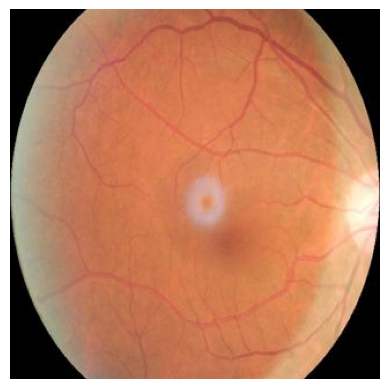

tensor(1.)
tensor(0.)
tensor([0.])


  1%|          | 1/103 [00:02<04:17,  2.52s/it]

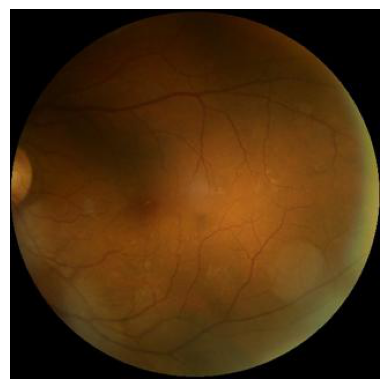

tensor(0.7216)
tensor(0.)
tensor([0.])


  2%|▏         | 2/103 [00:04<04:04,  2.42s/it]


KeyboardInterrupt: 

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/cnn_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = np.inf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training will happen on {device}.")

for epoch in range(EPOCHS):
    print(f"EPOCH {epoch_number + 1}")

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(model, epoch_number, writer, train_loader, device)

    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            if i > 10:
                break
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars(
        'Training vs. Validation Loss',
        {'Training' : avg_loss, 'Validation' : avg_vloss},
        epoch_number + 1
    )
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"model_{timestamp}_{epoch_number}"
        torch.save(model.state_dict(), model_path)


## CNN Exercise 2: Build and train a CNN with 5 Convolutional layers (**multi-label prediction**)
- Build a CNN with 5 Convolution + pooling layers for predicting all provided conditions
- Train with images of the size 320 x 320 (grayscale or RGB is up to you)
- Evaluate the model

In [ ]:
label_column = ['N', 'D', 'G', 'C', 'A', 'H', 'M']

## CNN Exercise 3: Apply transfer Learning (multi-label prediction)
- Use transfer learning for predicting all provided conditions
- Adapt the image size accordingly using torchvision transforms
- You can pick any pre-trained model provided by pytorch (better avoid the biggest models)
- Evaluate the model

## CNN Exercise 4: class weights
- Train the CNN from exercise 2 **or** 3 again using class weights (see for instance: https://saturncloud.io/blog/using-weights-in-crossentropyloss-and-bceloss-pytorch/).
- How does this affect the results? Is this better/similar/worse?

## CNN Exercise 5: Data augmentation
- Again, train the CNN from exercise 2 **or** 3. But now, add a few suitable (randomized) image transformations to increase the variation of the training data. This can be done via the torchvision transforms, see [documentation](https://docs.pytorch.org/vision/stable/transforms.html).
- How does this affect the results? Is this better/similar/worse?